- Filename: GHSOM_Times.ipynb
- Author: Tomas Hanzlik <hanzlto3@fit.cvut.cz>
- Created: 2026-04-22
- Description: Training and visualizations of the GHSOM model on the TIME Magazine dataset

# GHSOM training on TIME Magazine dataset

In [15]:
import numpy as np
import pandas as pd
from GHSOM import GHSOM
from help_functions import *
from nltk.stem import PorterStemmer, LancasterStemmer
from nltk.stem.snowball import SnowballStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
import nltk

Load data

In [16]:
df = pd.read_csv('../data/Time_magazine.csv')
y = df['file'].to_numpy()
X = df.drop(['file'], axis=1).to_numpy()

Create tokenizer and initialize tfidf vectorizer

In [17]:
stemmer = SnowballStemmer('english')

def english_tokenizer(text):  
    tokens = nltk.word_tokenize(text)
    stems = [stemmer.stem(t) for t in tokens if t.isalpha()]
    return stems

# TF-IDF transformation on the text with filtering on high and low frequency terms
tfidf_vectorizer = TfidfVectorizer(
    tokenizer = english_tokenizer,
    token_pattern = None,
    max_df=0.9,  
    min_df=0.01, 
)

Transform the text data into numerical matrix

In [18]:
X_sparse = tfidf_vectorizer.fit_transform(X.ravel())
X_tfidf = X_sparse.toarray()

Dimension of the embedded feature space

In [19]:
X_tfidf.shape

(420, 3902)

Initialize GHSOM

Details:
- Input dimension of size 3902
- Tau1 parameter of size 0.07
- Tau2 parameter of size 0.0035
- 15 training epoch for each map
- Initial learning rate of 0.5
- Beta of size 0.999
- QE metric used for vertical expansion
- Minimum of 5 samples for vertical expansion
- Maximum map dimension of 30 for individual GSOM
- Euclidean distance used to find neigbors
- Gaussian neigborhood function used
- Exponential decay function used

In [30]:
ghsom_deep = GHSOM(
    input_dim=X_tfidf.shape[1],
    t1=0.07,
    t2=0.0035,
    training_epoch_num=30)

In [31]:
ghsom_deep.train(X_tfidf, y)

Layer 0 Initialized, Global stopping criterion (tau2 * (qe0 or mqe0)): 1.3971
   -> Spawning child 1_0-0 Num of samples: 14, Error: 13.83 > 1.40)
   -> Spawning child 1_0-1 Num of samples: 75, Error: 75.88 > 1.40)
   -> Spawning child 1_0-2 Num of samples: 12, Error: 11.62 > 1.40)
   -> Spawning child 1_0-3 Num of samples: 12, Error: 11.13 > 1.40)
   -> Spawning child 1_0-4 Num of samples: 189, Error: 190.36 > 1.40)
   -> Spawning child 1_0-6 Num of samples: 24, Error: 22.71 > 1.40)
   -> Spawning child 1_0-7 Num of samples: 40, Error: 39.08 > 1.40)
   -> Spawning child 1_1-0 Num of samples: 6, Error: 5.25 > 1.40)
   -> Spawning child 1_1-1 Num of samples: 6, Error: 5.00 > 1.40)
   -> Spawning child 1_1-2 Num of samples: 11, Error: 10.95 > 1.40)
   -> Spawning child 1_1-6 Num of samples: 12, Error: 11.63 > 1.40)
   -> Spawning child 1_1-7 Num of samples: 10, Error: 8.32 > 1.40)
   -> Spawning child 1_0-1_0-0 Num of samples: 7, Error: 5.48 > 1.40)
   -> Spawning child 1_0-1_0-1 Num of s

Plot the hierarchical structure

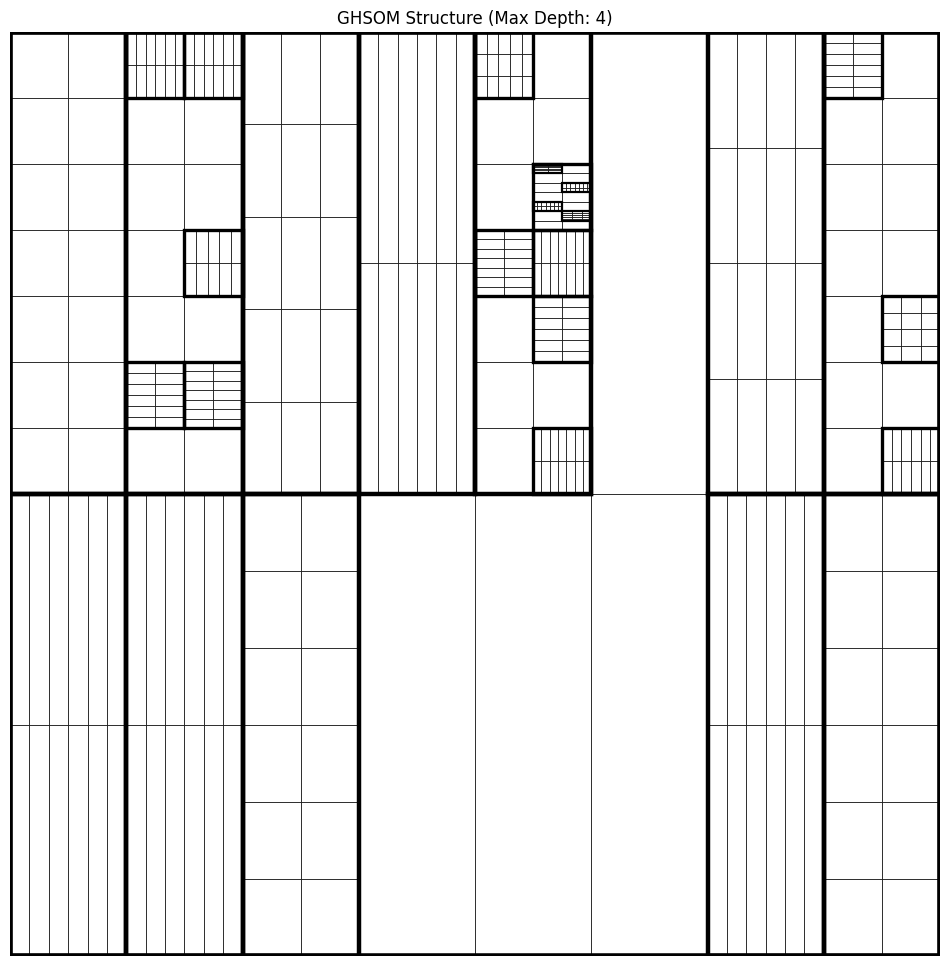

In [32]:
plot_ghsom(ghsom_deep, X_tfidf, y, False)

Describe each cell in the first and the second layer by its top 10 stems

In [33]:
terms = tfidf_vectorizer.get_feature_names_out()

In [34]:
for i in range(ghsom_deep.gsom_db["1"].current_row_num):
    for j in range(ghsom_deep.gsom_db["1"].current_col_num):
        print()
        print("------------------------")
        ghsom_deep.describe_node(X_tfidf, y, terms, "1", (i,j), 10, True)

        if f"1_{i}-{j}" in ghsom_deep.gsom_db.keys():
            sub_rows, sub_cols = ghsom_deep.gsom_db[f"1_{i}-{j}"].current_row_num, ghsom_deep.gsom_db[f"1_{i}-{j}"].current_col_num
            for k in range(sub_rows):
                for l in range(sub_cols):
                    ghsom_deep.describe_node(X_tfidf, y, terms, f"1_{i}-{j}", (k,l), 10, True)


------------------------

Map: 1 | Node: (0, 0)
Top 10 words: kenya, kenyatta, nehru, he, million, fewer, parti, region, ton, african, 
Samples: T018.html, T091.html, T110.html, T149.html, T177.html, T191.html, T254.html, T273.html, T427.html, T438.html, T475.html, T525.html, T529.html, T547.html, 
Map: 1_0-0 | Node: (0, 0)
Top 10 words: south, africa, verwoerd, white, black, match, polic, african, bottl, apartheid, 
Samples: T525.html, 
Map: 1_0-0 | Node: (0, 1)
Top 10 words: south, africa, white, black, match, bottl, game, verwoerd, australian, spectat, 
Samples: T475.html, 
Map: 1_0-0 | Node: (1, 0)
Top 10 words: africa, south, verwoerd, white, african, black, asian, jew, apartheid, polic, 
Samples: T110.html, 
Map: 1_0-0 | Node: (1, 1)
Top 10 words: africa, south, african, asian, white, jew, black, verwoerd, apartheid, match, 
Samples: T427.html, 
Map: 1_0-0 | Node: (2, 0)
Top 10 words: african, africa, asian, south, kenya, black, verwoerd, white, nationalist, island, 
Samples: T2